# Titanic BI Project


## Sections: Data Cleaning, Analysis, Visualization

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
df = pd.read_csv('/content/drive/MyDrive/Jamib/Titanic_Dataset.csv')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [137]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1039.000000,1309.000000,1309.000000,1298.000000,121.000000
mean,2.294882,0.381971,29.936641,0.498854,0.385027,40.903653,160.809917
std,0.837836,0.486055,14.705813,1.041658,0.865560,281.438825,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,120.000000,8.000000,9.000000,10000.000000,328.000000


In [138]:
df.shape

(1309, 14)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1039 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1298 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [140]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,270
sibsp,0
parch,0
ticket,0
fare,11
cabin,1014


<Axes: >

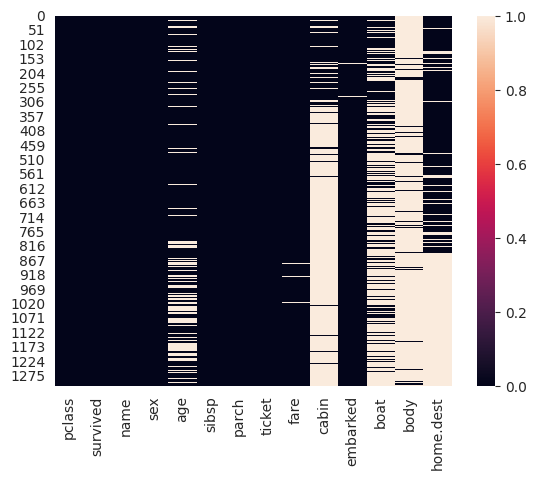

In [141]:
import seaborn as sns
sns.heatmap(df.isnull())

In [142]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

## Section 1 — Data Cleaning

In [143]:
df['age'].mean()

np.float64(29.936641000962464)

In [144]:
df['age'] = df['age'].fillna(29.937)

In [145]:
df['cabin'].mode()[0]

'C23 C25 C27'

In [146]:
df['cabin']=df['cabin'].fillna('C25')

In [147]:
df.drop(columns=['body'], inplace=True)

In [148]:
df['boat'] = df['boat'].fillna('NoBoat')

In [149]:
df['home.dest'] = df['home.dest'].fillna('Unknown')

In [150]:
df['fare'] = df.groupby('pclass')['fare'].transform(lambda x: x.fillna(x.median()))
df['fare_outlier'] = df['fare'] > 1000

In [151]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size']==1).astype(int)

df['age_group'] = pd.cut(df['age'], bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','Young','Adult','Senior'])

In [152]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
cabin,0


## Section 2 — Data Analysis

In [153]:
survival_rate = df['survived'].mean()
print('Survival Rate:', survival_rate)

Survival Rate: 0.3819709702062643


In [154]:
print(df.groupby('pclass')['survived'].mean())
print(df.groupby('sex')['survived'].mean())
print(df.groupby('age_group')['survived'].mean())
print(df.groupby('embarked')['survived'].mean())

pclass
1    0.619195
2    0.429603
3    0.255289
Name: survived, dtype: float64
sex
female     0.727468
male       0.191211
unknown    0.000000
Name: survived, dtype: float64
age_group
Child     0.574468
Teen      0.414141
Young     0.350943
Adult     0.407666
Senior    0.242424
Name: survived, dtype: float64
embarked
C    0.555556
Q    0.357724
S    0.331873
X    1.000000
Name: survived, dtype: float64


/tmp/ipykernel_13279/300185708.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [155]:
corr = df[['survived','pclass','age','fare','family_size']].corr()
corr

,survived,pclass,age,fare,family_size
survived,1.000000,-0.312469,-0.044679,0.078985,0.026876
pclass,-0.312469,1.000000,-0.364521,-0.144411,0.050027
age,-0.044679,-0.364521,1.000000,0.099055,-0.195087
fare,0.078985,-0.144411,0.099055,1.000000,0.043853
family_size,0.026876,0.050027,-0.195087,0.043853,1.000000


## Section 3 — Data Visualization

In [156]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio


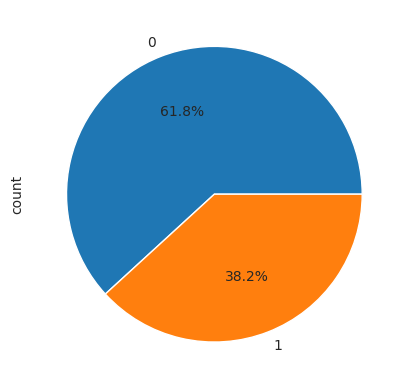

In [157]:
df['survived'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

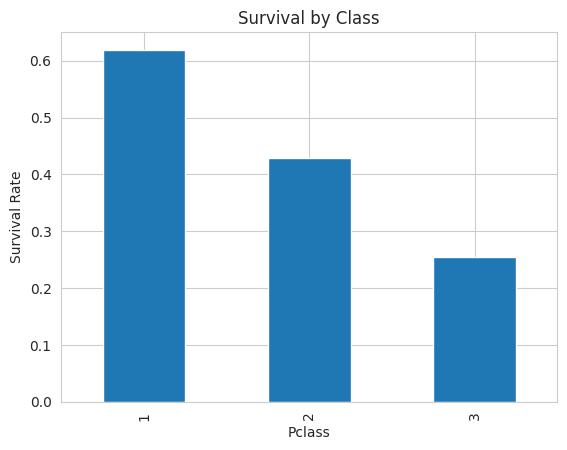

In [158]:
pclass_survival = df.groupby('pclass')['survived'].mean()

pclass_survival.plot(kind='bar')
plt.title('Survival by Class')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.show()

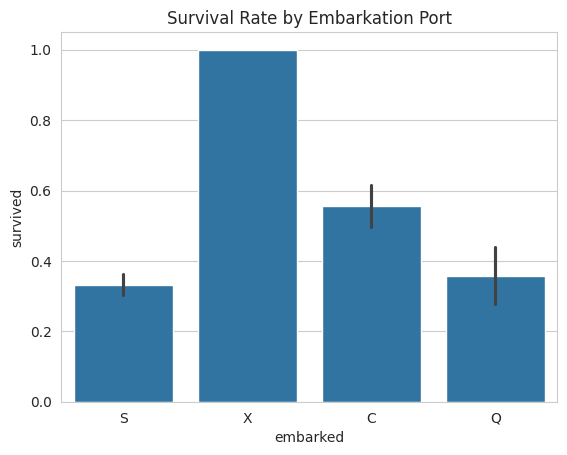

In [159]:
sns.barplot(x='embarked', y='survived', data=df)
plt.title('Survival Rate by Embarkation Port')
plt.show()

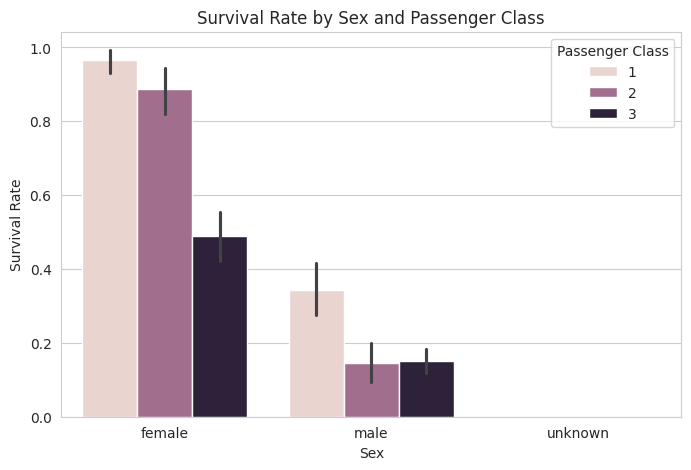

In [160]:
plt.figure(figsize=(8,5))

sns.barplot(x='sex', y='survived', hue='pclass', data=df)

plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')

plt.legend(title='Passenger Class')
plt.show()

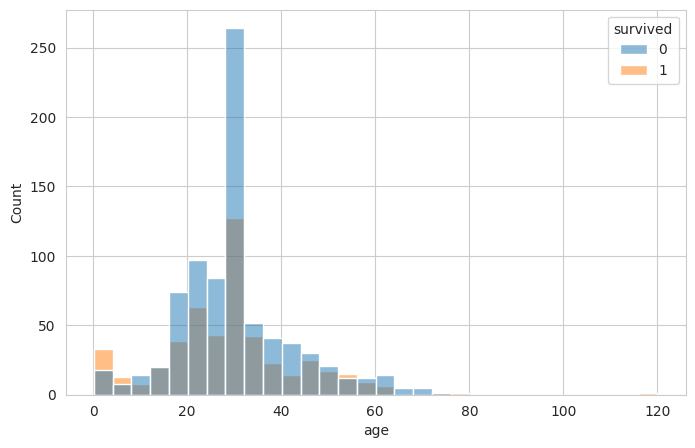

In [161]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='survived', bins=30)
plt.show()

In [162]:
pio.renderers.default = 'colab'
age_box_plot = px.box(df, x='survived',y='age',color='survived',title='Age Distribution by Survival')

age_box_plot.show()

In [163]:
fare_box_plot=px.box(df,x='survived',y='fare',color='survived',title='Fare distribution by survival')
fare_box_plot.show()

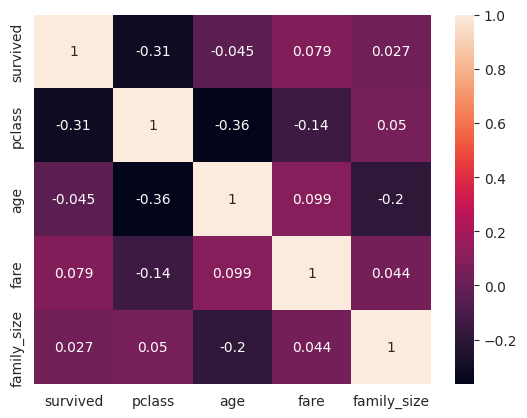

In [164]:
sns.heatmap(corr, annot=True)
plt.show()

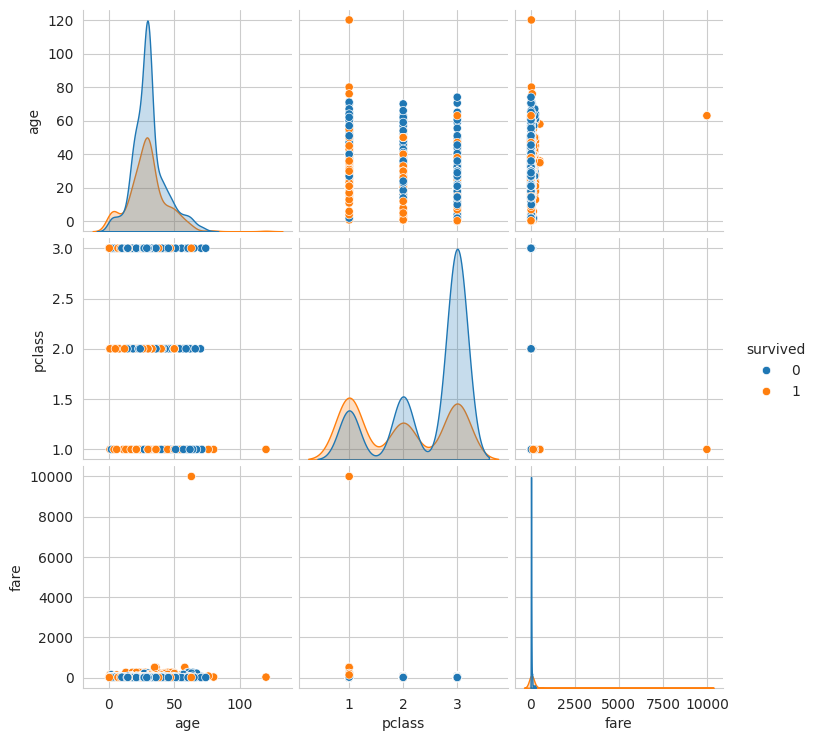

In [165]:
sns.pairplot(df, vars=['age','pclass','fare'], hue='survived')